In [ ]:
import pandas as pd
from pathlib import Path
import datetime as dt
import seaborn as sns
import numpy as np

In [ ]:
datadir = Path().absolute().parent / "evaluation/working"
locs = ['PABE', 'PAFA', 'PANC', 'PABR']
filepattern = 'era5_{airport}_{var}_1981_2020.csv'

### Single file prototyping

In [ ]:
var = 't2m'
location = 'PAFA'
fp = (datadir / filepattern.format(airport=location, var=var))

In [ ]:
inDF = pd.read_csv(fp)
inDF['Time'] = pd.to_datetime(inDF['time'])
inDF['t2m'] = inDF['t2m'] - 273.15
inDF.set_index('Time', inplace=True)
monthlyDF =  inDF[[var]].groupby(
        pd.Grouper(freq='M')).mean()
monthlyDF['year'] = monthlyDF.index.year
monthlyDF['month'] = monthlyDF.index.month
monthlyDF
# inDF

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_59694/3745958544.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()


,t2m,year,month
Time,,,
1981-01-31,-5.587987,1981,1
1981-02-28,-14.614816,1981,2
1981-03-31,-2.477962,1981,3
1981-04-30,0.214134,1981,4
1981-05-31,13.565512,1981,5
...,...,...,...
2020-08-31,14.956621,2020,8
2020-09-30,8.482585,2020,9
2020-10-31,-1.228963,2020,10


In [ ]:
lat, lon = inDF.iloc[0].latitude, inDF.iloc[0].longitude
outfn = datadir / f'era5_{location}_Tmean_1981_2020_monthly.csv'

with open(outfn, 'w') as dst:
    dst.write(f"# Monthly mean ERA5 temperature for {location}, lon/lat = {lon}/{lat}\n")
    dst.write(f"# Chris Waigl, cwaigl@alaska.edu, {dt.datetime.now()}\n" )
    monthlyDF.to_csv(dst, float_format='%.3f')

<Axes: xlabel='month'>

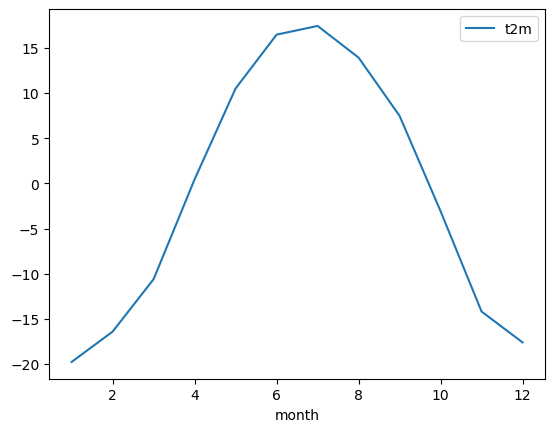

In [ ]:
monthlyDF.groupby('month').mean().drop(columns=['year']).plot()

<Axes: xlabel='month', ylabel='t2m'>

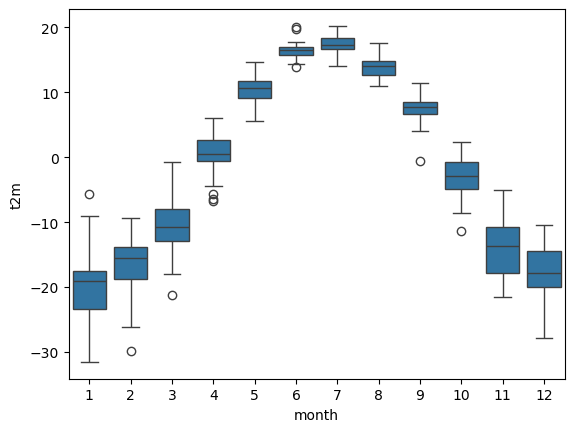

In [ ]:
sns.boxplot(data=monthlyDF, x='month', y='t2m')

<Axes: xlabel='month', ylabel='t2m'>

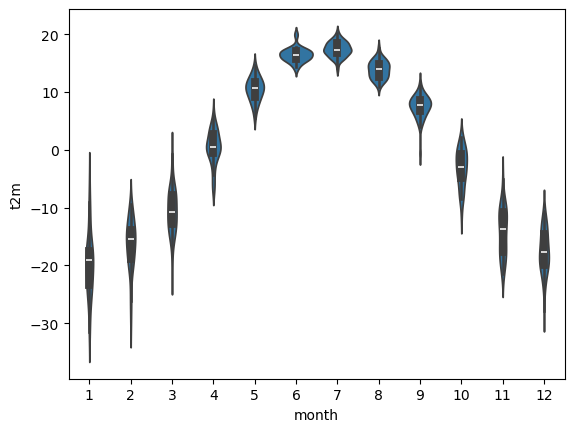

In [ ]:
sns.violinplot(data=monthlyDF, x='month', y='t2m')

### All files 

In [ ]:
for loc in locs:
    for var in ['Tmean', 'precip', 'wsp']:
        outfn = datadir / f'era5_{loc}_{var}_1981_2020_monthly.csv'
        match var:
            case 'Tmean':
                fp = (datadir / filepattern.format(airport=loc, var='t2m'))
                inDF = pd.read_csv(fp)
                inDF['Time'] = pd.to_datetime(inDF['time'])
                inDF['t2m'] = inDF['t2m'] - 273.15
                inDF.set_index('Time', inplace=True)
                monthlyDF =  inDF[['t2m']].groupby(
                        pd.Grouper(freq='M')).mean()
                monthlyDF['year'] = monthlyDF.index.year
                monthlyDF['month'] = monthlyDF.index.month
                lat, lon = inDF.iloc[0].latitude, inDF.iloc[0].longitude
                with open(outfn, 'w') as dst:
                    dst.write(f"# Monthly mean ERA5 temperature for {loc}, lon/lat = {lon}/{lat}\n")
                    dst.write(f"# Chris Waigl, cwaigl@alaska.edu, {dt.datetime.now()}\n" )
                    monthlyDF.to_csv(dst, float_format='%.3f')
            case 'precip':
                fp = (datadir / filepattern.format(airport=loc, var='tp'))
                inDF = pd.read_csv(fp)
                inDF['Time'] = pd.to_datetime(inDF['time'])
                inDF.set_index('Time', inplace=True)
                monthlyDF =  inDF[['tp']].groupby(
                        pd.Grouper(freq='M')).sum()
                monthlyDF['year'] = monthlyDF.index.year
                monthlyDF['month'] = monthlyDF.index.month
                lat, lon = inDF.iloc[0].latitude, inDF.iloc[0].longitude
                with open(outfn, 'w') as dst:
                    dst.write(f"# Monthly total ERA5 precipitation for {loc}, lon/lat = {lon}/{lat}\n")
                    dst.write(f"# Chris Waigl, cwaigl@alaska.edu, {dt.datetime.now()}\n" )
                    monthlyDF.to_csv(dst, float_format='%.3f')
            case 'wsp':
                fp1 = (datadir / filepattern.format(airport=loc, var='u10'))
                inDF = pd.read_csv(fp1)
                fp2 = (datadir / filepattern.format(airport=loc, var='v10'))
                inDF2 = pd.read_csv(fp2)
                inDF['wsp10'] = np.sqrt(inDF.u10**2 + inDF2.v10**2)
                inDF['Time'] = pd.to_datetime(inDF['time'])
                inDF.set_index('Time', inplace=True)
                monthlyDF =  inDF[['wsp10']].groupby(
                        pd.Grouper(freq='M')).mean()
                monthlyDF['year'] = monthlyDF.index.year
                monthlyDF['month'] = monthlyDF.index.month
                lat, lon = inDF.iloc[0].latitude, inDF.iloc[0].longitude
                with open(outfn, 'w') as dst:
                    dst.write(f"# Monthly mean ERA5 wind speed for {loc}, lon/lat = {lon}/{lat}\n")
                    dst.write(f"# Chris Waigl, cwaigl@alaska.edu, {dt.datetime.now()}\n" )
                    monthlyDF.to_csv(dst, float_format='%.3f')               
                

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_59694/3724815045.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_59694/3724815045.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_59694/3724815045.py:43: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_59694/3724815045.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_59694/3724815045.py:26: FutureWarning: 'M' is deprecated and will be removed in a future v

In [ ]:
monthlyDF

,wsp10,year,month
Time,,,
1981-01-31,6.375476,1981,1
1981-02-28,6.044203,1981,2
1981-03-31,7.104958,1981,3
1981-04-30,4.628825,1981,4
1981-05-31,5.304465,1981,5
...,...,...,...
2020-08-31,4.638853,2020,8
2020-09-30,5.691141,2020,9
2020-10-31,5.788386,2020,10


<Axes: xlabel='month', ylabel='wsp10'>

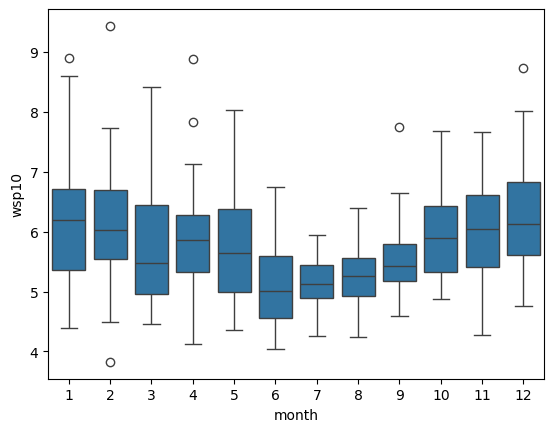

In [ ]:
sns.boxplot(data=monthlyDF, x='month', y='wsp10')

In [ ]:
fp = datadir / "era5_PABE_wsp_1981_2020_monthly.csv"
data = pd.read_csv(fp, skiprows=2)
data

,Time,wsp10,year,month
0,1981-01-31,5.764,1981,1
1,1981-02-28,6.369,1981,2
2,1981-03-31,5.746,1981,3
3,1981-04-30,4.461,1981,4
4,1981-05-31,3.862,1981,5
...,...,...,...,...
475,2020-08-31,2.901,2020,8
476,2020-09-30,4.540,2020,9
477,2020-10-31,3.811,2020,10
478,2020-11-30,5.228,2020,11


<Axes: xlabel='month', ylabel='wsp10'>

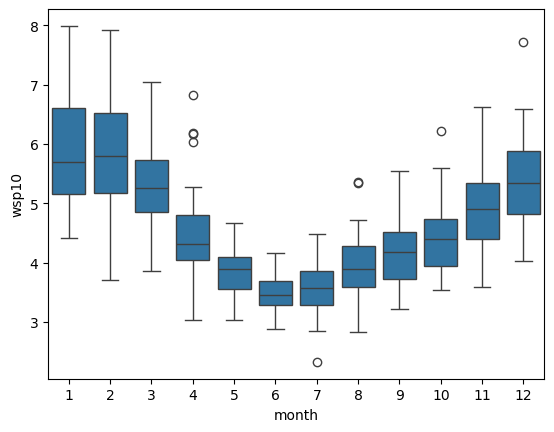

In [ ]:
sns.boxplot(data=data, x='month', y='wsp10')